In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# -------------------------------------------------
# Create FrozenLake Environment
# -------------------------------------------------

env = gym.make("FrozenLake-v1", is_slippery=True)

n_states = env.observation_space.n
n_actions = env.action_space.n

print("Number of states:", n_states)
print("Number of actions:", n_actions)

Number of states: 16
Number of actions: 4


In [12]:
# -------------------------------------------------
# Hyperparameters
# -------------------------------------------------

alpha = 0.2
gamma = 0.92
epsilon = 1.0
epsilon_decay = 0.995
epsilon_min = 0.01

episodes = 10000
max_steps = 100

In [13]:
# -------------------------------------------------
# Initialize Q-table
# -------------------------------------------------

Q = np.zeros((n_states, n_actions))


# -------------------------------------------------
# Epsilon-Greedy Action Selection
# -------------------------------------------------

def choose_action(state):
    if np.random.random() < epsilon:
        return env.action_space.sample()
    else:
        return np.argmax(Q[state])

In [14]:
# -------------------------------------------------
# Q-Learning Training
# -------------------------------------------------

episode_rewards = []

for episode in range(episodes):

    state, info = env.reset()
    total_reward = 0

    for step in range(max_steps):

        # Choose action
        action = choose_action(state)

        # Take action
        next_state, reward, terminated, truncated, info = env.step(action)

        # Q-Learning update
        Q[state, action] = Q[state, action] + alpha * (
            reward + gamma * np.max(Q[next_state]) - Q[state, action]
        )

        state = next_state
        total_reward += reward

        if terminated or truncated:
            break

    episode_rewards.append(total_reward)

    # Decay epsilon
    epsilon = max(epsilon_min, epsilon * epsilon_decay)


# State-value function
state_values = np.max(Q, axis=1)

# Learned policy
learned_policy = np.argmax(Q, axis=1)

In [15]:
# -------------------------------------------------
# Display Functions
# -------------------------------------------------

def print_value_function(values):
    print("\nEstimated State-Value Function:")
    print(np.round(values.reshape(4, 4), 3))


def print_policy(policy):
    action_symbols = {
        0: "L",
        1: "D",
        2: "R",
        3: "U"
    }

    policy_grid = np.array(
        [action_symbols[action] for action in policy]
    ).reshape(4, 4)

    print("\nLearned Policy:")
    print(policy_grid)


In [16]:
# -------------------------------------------------
# Output
# -------------------------------------------------
print("Name:Rithika K")
print("Reg:212224230230")

print("\nFinal Q-table:")
print(np.round(Q, 3))

print_value_function(state_values)
print_policy(learned_policy)

average_reward = np.mean(episode_rewards[-1000:])
print("\nAverage reward over last 1000 episodes:", average_reward)

Name:Rithika K
Reg:212224230230

Final Q-table:
[[0.109 0.07  0.069 0.072]
 [0.036 0.058 0.028 0.073]
 [0.077 0.041 0.029 0.036]
 [0.024 0.025 0.026 0.064]
 [0.127 0.05  0.088 0.071]
 [0.    0.    0.    0.   ]
 [0.018 0.042 0.045 0.022]
 [0.    0.    0.    0.   ]
 [0.084 0.13  0.121 0.163]
 [0.16  0.189 0.192 0.115]
 [0.144 0.146 0.136 0.106]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.213 0.189 0.237 0.24 ]
 [0.385 0.391 0.441 0.486]
 [0.    0.    0.    0.   ]]

Estimated State-Value Function:
[[0.109 0.073 0.077 0.064]
 [0.127 0.    0.045 0.   ]
 [0.163 0.192 0.146 0.   ]
 [0.    0.24  0.486 0.   ]]

Learned Policy:
[['L' 'U' 'L' 'U']
 ['L' 'L' 'R' 'L']
 ['U' 'R' 'D' 'L']
 ['L' 'U' 'U' 'L']]

Average reward over last 1000 episodes: 0.533


Name:Rithika K
Reg:212224230230


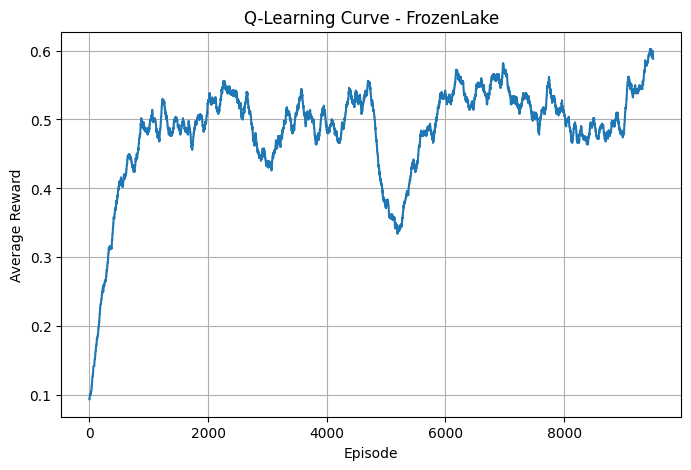

In [17]:
# -------------------------------------------------
# Plot Learning Curve
# -------------------------------------------------

window = 500

moving_average = np.convolve(
    episode_rewards,
    np.ones(window) / window,
    mode="valid"
)
print("Name:Rithika K")
print("Reg:212224230230")

plt.figure(figsize=(8, 5))
plt.plot(moving_average)
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("Q-Learning Curve - FrozenLake")
plt.grid(True)
plt.show()

env.close()